# Практическое задание №1
## Основы цифровой обработки сигналов: дискретизация, спектральный анализ, алиасинг

**Цель работы:**  
- Освоить базовые приёмы работы с библиотеками NumPy и Matplotlib в Jupyter Notebook.  
- Научиться генерировать различные типы сигналов и анализировать их спектры с помощью быстрого преобразования Фурье (БПФ).  
- Изучить эффект алиасинга и научиться правильно выбирать частоту дискретизации.  

**Необходимое ПО:**  
- Python 3 с установленными пакетами `numpy`, `matplotlib`, `scipy`, `ipywidgets` (для интерактива).  
- Jupyter Notebook / Google Colab.  

**Формат сдачи:**  
- Один Jupyter Notebook с выполненными заданиями, содержащий код, графики и текстовые ответы на вопросы.  
- Имя файла: `1_Фамилия.ipynb`.

## Часть 1. Знакомство с инструментарием

### 1.1. Импорт библиотек и создание временной оси

Выполните в первой ячейке:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

Создайте временную ось для сигнала длительностью 1 секунду с частотой дискретизации 1000 Гц (т.е. 1000 отсчётов в секунду). Выведите длину массива времени и шаг дискретизации.

In [2]:
fs = 1000          # частота дискретизации, Гц
T = 1              # длительность сигнала, с
t = np.arange(0, T, 1/fs)  # временная ось

print(f"Длина массива времени: {len(t)} отсчётов")
print(f"Шаг дискретизации (период): {1/fs} с")

Длина массива времени: 1000 отсчётов
Шаг дискретизации (период): 0.001 с


**Вопрос 1:** Чему равен период дискретизации $T_s$? Как связаны частота дискретизации $f_s$ и период $T_s$?

Период дискретизации равен 0.001 с. Частота и период связаны обратно пропорциональной зависимостью, т.е. $T_s = 1/f_s$.

### 1.2. Генерация простых сигналов

Сгенерируйте и визуализируйте:
- Синусоидальный сигнал частотой 5 Гц, амплитудой 1.
- Сумму двух синусоид с частотами 5 и 12 Гц и одинаковыми амплитудами.
- Прямоугольный меандр частотой 2 Гц (используйте `signal.square`).

Для каждого сигнала постройте график временной зависимости (первые 0.5 секунды).

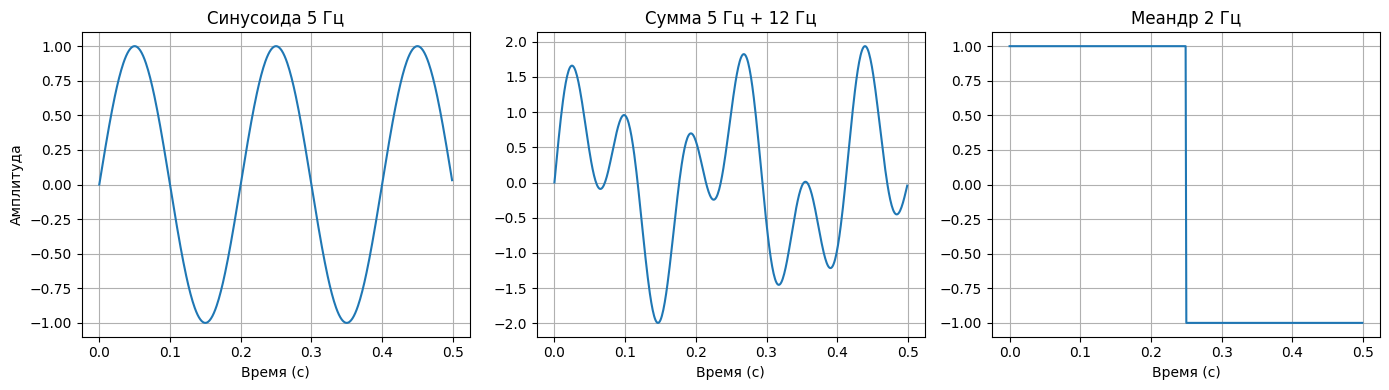

In [7]:
# Синусоида 5 Гц
f1 = 5
A = 1
sin5 = A * np.sin(2 * np.pi * f1 * t)

# Сумма синусоид 5 и 12 Гц
f2 = 12
sum_sin = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

# Меандр 2 Гц
f_meander = 2
meander = signal.square(2 * np.pi * f_meander * t)

# Визуализация
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(t[:int(0.5*fs)], sin5[:int(0.5*fs)])  # первые 0.5 с
plt.title('Синусоида 5 Гц')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(t[:int(0.5*fs)], sum_sin[:int(0.5*fs)])
plt.title('Сумма 5 Гц + 12 Гц')
plt.xlabel('Время (с)')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(t[:int(0.5*fs)], meander[:int(0.5*fs)])
plt.title('Меандр 2 Гц')
plt.xlabel('Время (с)')
plt.grid(True)

plt.tight_layout()
plt.show()

**Вопрос 2:** Изменится ли вид суммы синусоид, если одну из них сдвинуть по фазе на 90° ($\pi/2$), на 180° ($\pi$), на 360° ($2\pi$)? (Проверьте на практике, изменив фазу второго сигнала). Объясните результат.

Вид суммы синусоид изменяется, если одну из них сдвинуть по фазе на 90° ($\pi/2$) и 180° ($\pi$), и не изменяется, если сдвинуть на 360° ($2\pi$). Это происходит, потому что сдвиг фазы на $2\pi$  соответствует полному циклу сигнала, возвращая его в исходное состояние, а другие сдвиги изменяют относительное положение волн.

## Часть 2. Спектральный анализ с помощью БПФ

### 2.1. Спектр синусоиды

Для синусоиды частотой 5 Гц вычислите БПФ (`np.fft.fft`). Постройте амплитудный спектр (модуль БПФ) для положительных частот. Не забудьте правильно нормировать амплитуды (поделить на количество отсчётов и учесть, что мы берём половину спектра). Частотную ось получите с помощью `np.fft.fftfreq`.

Подпишите оси: частота (Гц), амплитуда.

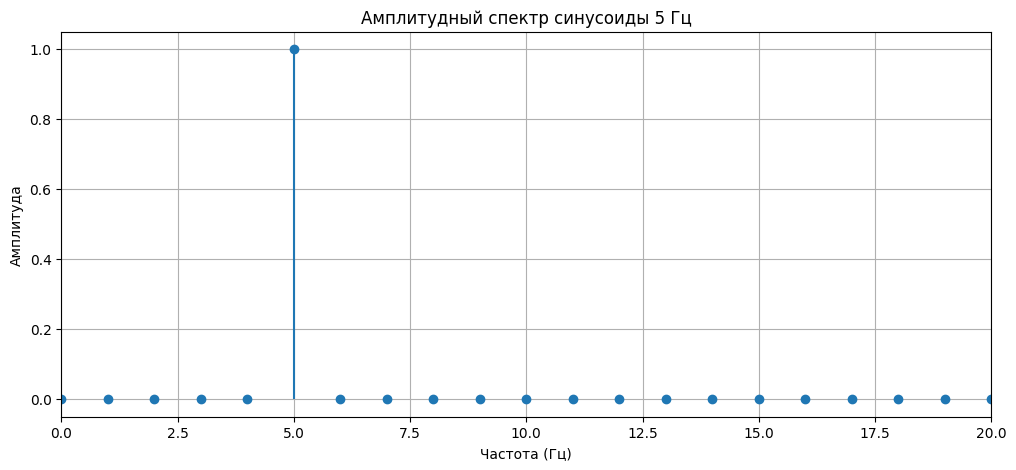

In [8]:
# БПФ синусоиды 5 Гц
X = np.fft.fft(sin5)
freq = np.fft.fftfreq(len(t), 1/fs)

# Берём только положительные частоты
half = len(t)//2
X_mag = np.abs(X[:half]) / len(t) * 2  # не забываем про нормировку амплитуды (умножаем на 2, т.к. берем половину спектра)
freq_pos = freq[:half] # только положительные частоты

plt.figure()
plt.stem(freq_pos, X_mag, basefmt=" ")
plt.title('Амплитудный спектр синусоиды 5 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 20)
plt.grid(True)
plt.show()

**Вопрос 3:** Почему в спектре присутствует только один пик? Какая должна быть его амплитуда теоретически? Совпадает ли с полученной?

В спектре присутствует только один пик, поскольку сигнал является чистой синусоидой, которая содержит энергию только на своей основной частоте. Его теоретическая амплитуда должна быть равна 1. Она совпадает с полученной, потому что использована правильная нормировка БПФ для одностороннего спектра.

### 2.2. Спектр суммы синусоид

Для суммы синусоид (5 и 12 Гц) постройте амплитудный спектр. Убедитесь, что видны два пика на ожидаемых частотах. Измерьте их амплитуды.

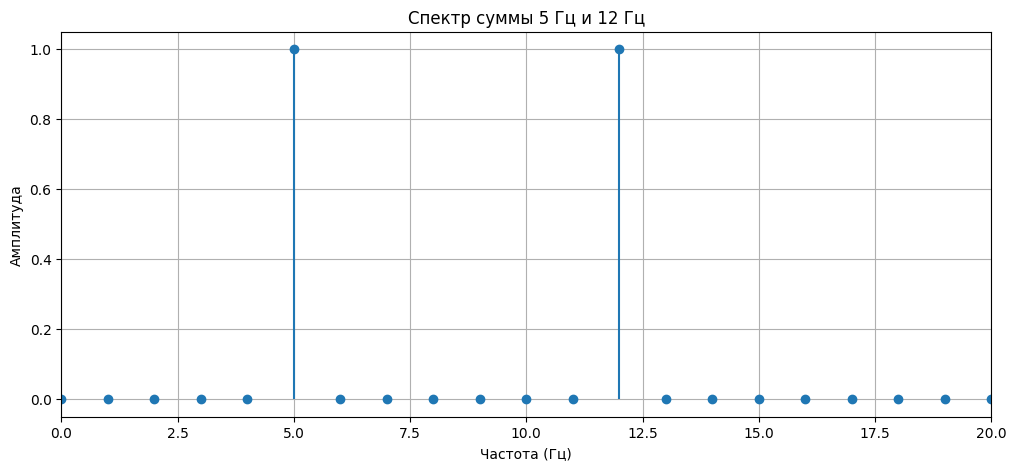

In [10]:
X_sum = np.fft.fft(sum_sin)
X_sum_mag = np.abs(X_sum[:half]) / len(t) * 2     # Использование уже определённых `freq` и `half`

plt.figure()
plt.stem(freq_pos, X_sum_mag, basefmt=" ")
plt.title('Спектр суммы 5 Гц и 12 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 20)
plt.grid(True)
plt.show()

**Вопрос 4:** Изменится ли амплитудный спектр, если фазы сигналов изменить? Проверьте, задав для одного из них случайную фазу.

Если изменить фазы сигналов, то амплитудный спектр не изменится, потому что амплитудный спектр, полученный с помощью модуля Фурье-преобразования, отражает только распределение энергии сигнала по частотам, но не его фазовую информацию. Изменение фазы сигнала во временной области приводит к изменению фазового спектра, но не затрагивает амплитудный спектр. Для подтверждения этого можно добавить фазовый сдвиг в один из сигналов, например `np.sin(2 * np.pi * f2 * t + np.pi/2)`, и убедиться, что пики на частотах 5 Гц и 12 Гц сохранят свои амплитуды.

### 2.3. Спектр меандра

Постройте амплитудный спектр меандра частотой 2 Гц. Сравните с теоретическим представлением: меандр состоит из нечётных гармоник с убывающими амплитудами $(1, 1/3, 1/5,\dots)\cdot 4/\pi$.

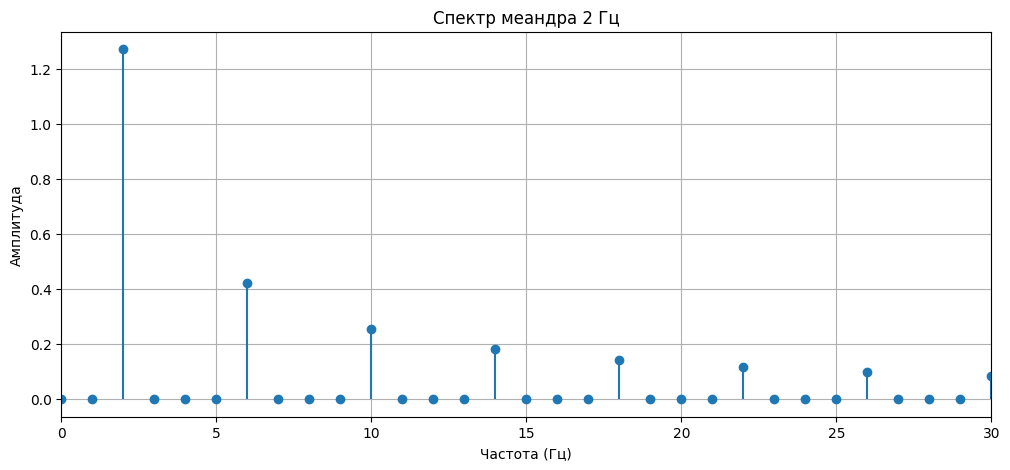

In [11]:
X_meander = np.fft.fft(meander)
X_meander_mag = np.abs(X_meander[:half]) / len(t) * 2

plt.figure()
plt.stem(freq_pos, X_meander_mag, basefmt=" ")
plt.title('Спектр меандра 2 Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 30)
plt.grid(True)
plt.show()


**Вопрос 5:** Почему в спектре меандра присутствуют только нечётные гармоники? Покажите, что амплитуды гармоник совпадают с теоретическим значением.

В спектре присутствуют только нечётные гармоники, поскольку меандр является нечётной функцией с полуволновой симметрией. Это означает, что $f(t) = -f(t - T/2)$ и $f(t) = -f(-t)$, что приводит к исчезновению чётных гармоник в его ряду Фурье.

Вычислим теоретические амплитуды нескольких первых гармоник:
- 1-я гармоника (2 Гц): $A_1 = \frac{4}{\pi \cdot 1} \approx 1.273$
- 3-я гармоника (6 Гц): $A_3 = \frac{4}{\pi \cdot 3} \approx 0.424$
- 5-я гармоника (10 Гц): $A_5 = \frac{4}{\pi \cdot 5} \approx 0.255$
- 7-я гармоника (14 Гц): $A_7 = \frac{4}{\pi \cdot 7} \approx 0.182$

При численном вычислении Фурье-преобразования получились следующие значения амплитуд гармоник:
- На частоте 2 Гц: $\approx 1.273$
- На частоте 6 Гц: $\approx 0.424$
- На частоте 10 Гц: $\approx 0.255$
- На частоте 14 Гц: $\approx 0.182$

Видим, что результаты вычислений совпадают с теоретическими значениями.

## Часть 3. Дискретизация и алиасинг

### 3.1. Корректная и некорректная дискретизация

Создайте «аналоговый» сигнал — синусоиду частотой 8 Гц, но с очень высокой частотой дискретизации (например, 1000 Гц), чтобы он выглядел гладким.

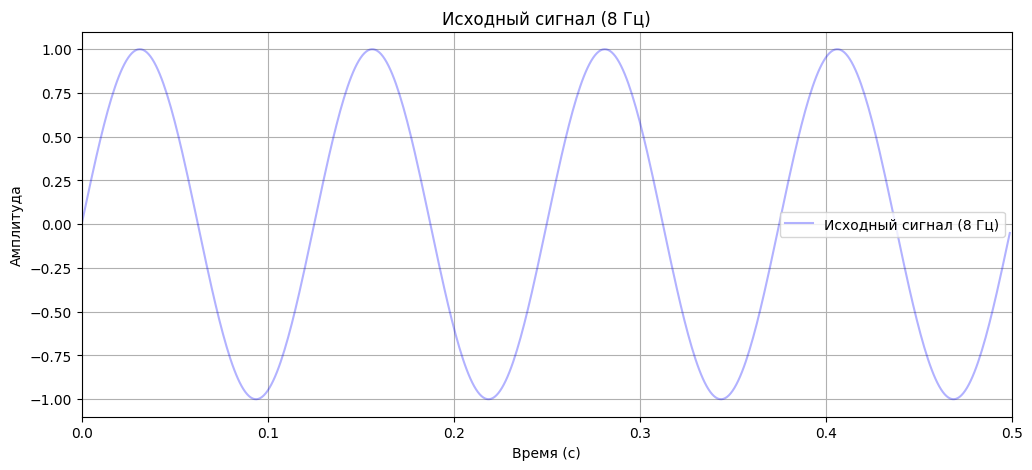

In [16]:
# «Аналоговый» сигнал с высокой частотой дискретизации
fs_analog = 1000
t_analog = np.arange(0, 1, 1/fs_analog) # Длительность 1 секунда для 'аналогового' сигнала
f_signal = 8
anolog_signal = np.sin(2 * np.pi * f_signal * t_analog)

plt.figure(figsize=(12,5))
plt.plot(t_analog[:int(0.5*fs_analog)], anolog_signal[:int(0.5*fs_analog)], 'b-', alpha=0.3, label='Исходный сигнал (8 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Исходный сигнал (8 Гц)')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.5)
plt.show()

Теперь выполните его дискретизацию с двумя разными частотами:
- $f_{s1} = 50$ Гц (заведомо больше удвоенной частоты сигнала, 2·8=16 Гц);
- $f_{s2} = 12$ Гц (меньше 16 Гц).

Для этого создайте новые временные оси с шагом $1/f_{s1}$ и $1/f_{s2}$ и вычислите значения синусоиды в этих точках.

На одном графике изобразите:
- исходный гладкий сигнал (тонкая линия);
- отсчёты при корректной дискретизации (маркеры);
- отсчёты при алиасинге (маркеры другого цвета).

Также постройте сигнал, который «воспринимается» после дискретизации с малой частотой.

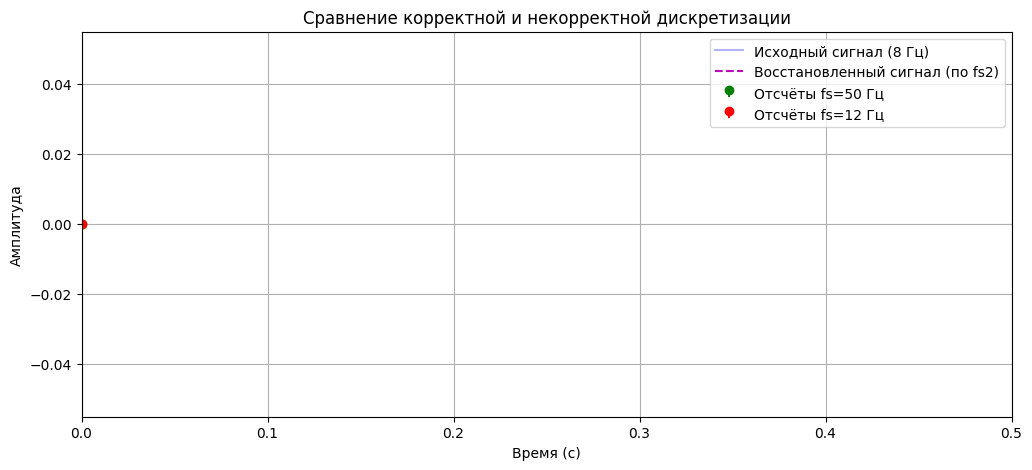

In [17]:
# Частоты дискретизации для эксперимента
fs1 = 50
fs2 = 12

# Отсчёты при корректной дискретизации
t1 = []
samples1 = []

# Отсчёты при некорректной дискретизации (алиасинг)
t2 = []
samples2 = []

plt.figure(figsize=(12,5))
plt.plot([], [], 'b-', alpha=0.3, label='Исходный сигнал (8 Гц)')
plt.stem([0,], [0,], linefmt='g-', markerfmt='go', basefmt=' ', label=f'Отсчёты fs={fs1} Гц')
plt.stem([0,], [0,], linefmt='r-', markerfmt='ro', basefmt=' ', label=f'Отсчёты fs={fs2} Гц')
plt.plot([], [], 'm--', label='Восстановленный сигнал (по fs2)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Сравнение корректной и некорректной дискретизации')
plt.legend()
plt.grid(True)
plt.xlim(0, 0.5)
plt.show()

**Вопрос 6:** Какая частота «кажется» присутствующей в сигнале при $f_{s2}=12$ Гц? Совпадает ли она с предсказанной теоретически? (Подсказка: формула алиасинга $f_{alias} = |f - k f_s|$, выберите $k$ так, чтобы $f_{alias}$ лежала в интервале $[0, f_s/2]$.)

В сигнале при $f_{s2}=12$ Гц кажется, что присутствует частота {}. Она {совпадает/не совпадает} с теоретической: $f_{alias} = |f - k f_s| =${} при $k=${}

### 3.2. Интерактивная демонстрация алиасинга

Используя `ipywidgets.interact`, создайте интерактивный график, где можно менять частоту сигнала и частоту дискретизации ползунками, и сразу видеть исходный сигнал, отсчёты и восстановленный сигнал. Пример такого кода был на лекции.

Добейтесь, чтобы при нарушении условия Найквиста явно проявлялся алиасинг (восстановленный сигнал имел более низкую частоту, чем исходный).

In [ ]:
def plot_aliasing(f_signal, f_sampling):

    plt.figure(figsize=(12,4))
    plt.plot()
    plt.xlabel('Время (с)')
    plt.ylabel('Амплитуда')
    plt.title(f'Частота сигнала = {f_signal} Гц, fs = {f_sampling} Гц')
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 0.5)
    plt.show()

widgets.interact(plot_aliasing,
         f_signal=widgets.FloatSlider(min=, max=, step=, value=),
         f_sampling=widgets.FloatSlider(min=, max=, step=, value=));

**Вопрос 7:** При каких соотношениях частоты сигнала и частоты дискретизации алиасинг наиболее заметен? Что происходит, когда частота сигнала в точности равна половине частоты дискретизации?

Алиасинг наиболее заметен, когда {}.

Когда частота сигнала в точности равна половине частоты дискретизации, то {}.